# Preliminaries

In [1]:
import geopandas as gpd
from pathlib import Path
from shapely.geometry import Point
from matplotlib import pyplot as plt
import pandas as pd
import yaml
import numpy as np
import seaborn as sns
from matplotlib.ticker import MultipleLocator
from pointpats import PointPattern
from canada_wildfires.plot_functions import pointplot_grouped

In [2]:
root = Path.cwd().parent
assets_folder = Path(root, "assets")
plot_folder = Path(assets_folder, "plots")
data_folder = Path(root, "data")
with Path(root, "conf", "config").with_suffix(".yaml").open("r") as configfile:
    conf = yaml.safe_load(configfile)

In [3]:
if not any(data_folder.iterdir()):
    %run ../src/canada_wildfires/data.py

In [ ]:
%matplotlib inline
plt.style.use("ggplot")
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'grid.color': '#e5e5e5',
    'grid.linestyle': '-',
    'grid.linewidth': 0.8,
})
pd.options.display.float_format = '{:.2f}'.format
def save_fig(plotname:str) -> None:
    plt.savefig(Path(plot_folder, plotname).with_suffix(".png"))

In [5]:
canada = gpd.read_parquet(Path(assets_folder, "canada.pq"))

# Data Preprocessing and Description

In [6]:
fires = gpd.read_file(Path(root, "data", "CANADA_WILDFIRES.csv"))
fires = gpd.GeoDataFrame(fires,
                         geometry = [Point(xy) for xy in zip(fires["LONGITUDE"], fires["LATITUDE"])],
                         crs = conf["crs"])
fires = fires[fires.within(canada.union_all())]
fires["SIZE_HA"] = pd.to_numeric(fires["SIZE_HA"])
fires = fires[fires["ECOZ_NAME"] != " "]
fires["REP_DATE"] = pd.to_datetime(fires["REP_DATE"], errors="coerce")
fires = fires.dropna(subset=["REP_DATE"])
fires["year"] = fires["REP_DATE"].dt.year
fires["REP_DATE"].dt.month
fires["SIZE_HA_LOG"] = np.log1p(fires["SIZE_HA"])

fires.isna().sum()


FID            0
SRC_AGENCY     0
LATITUDE       0
LONGITUDE      0
REP_DATE       0
SIZE_HA        0
CAUSE          0
PROTZONE       0
ECOZ_NAME      0
geometry       0
year           0
SIZE_HA_LOG    0
dtype: int64

In [7]:
fires.groupby("ECOZ_NAME")["ECOZ_NAME"].value_counts()

ECOZ_NAME
Atlantic Maritime      22238
Boreal Cordillera       9026
Boreal PLain           77310
Boreal Shield East     67451
Boreal Shield West     56683
Hudson Plain            2049
MixedWood Plain         4446
Montane Cordillera    120733
Northern Arctic            4
Pacific Maritime       19616
Prairie                 1399
Southern Arctic          265
Taiga Cordillera        1077
Taiga Plain            16855
Taiga Shield East       1467
Taiga Shield West       7949
Name: count, dtype: int64

Northern Arctic and Southern Arctic appear to have exceptionally low counts of wildfires, next to the fact that wildfires in the arctic seem questionable anyway, so these observations will be removed:

In [8]:
fires = fires[~fires["ECOZ_NAME"].str.contains("Arctic")]

In [9]:
fires.groupby(fires["REP_DATE"].dt.year).size().head(10)

REP_DATE
1930       1
1946      19
1947      26
1948      19
1949      11
1950    1370
1951    1654
1952    1571
1953    1244
1954     682
dtype: int64

Also in the years before 1950 there seem to be limited observations available, so only for the years from 1950 on data will be considered:

In [10]:
fires = fires[fires.REP_DATE.dt.year >= 1950]

For plotting purposes it makes sense to have a spatial extent to prevent geoplot from "zooming in" when only a small subarea is covered:

In [11]:
extent = dict(zip(["xmin", "ymin", "xmax", "ymax"], fires.total_bounds.tolist()))

Now lets vizualize the wildfire locations but consider only say 5 year chunks the prevent overplotting:

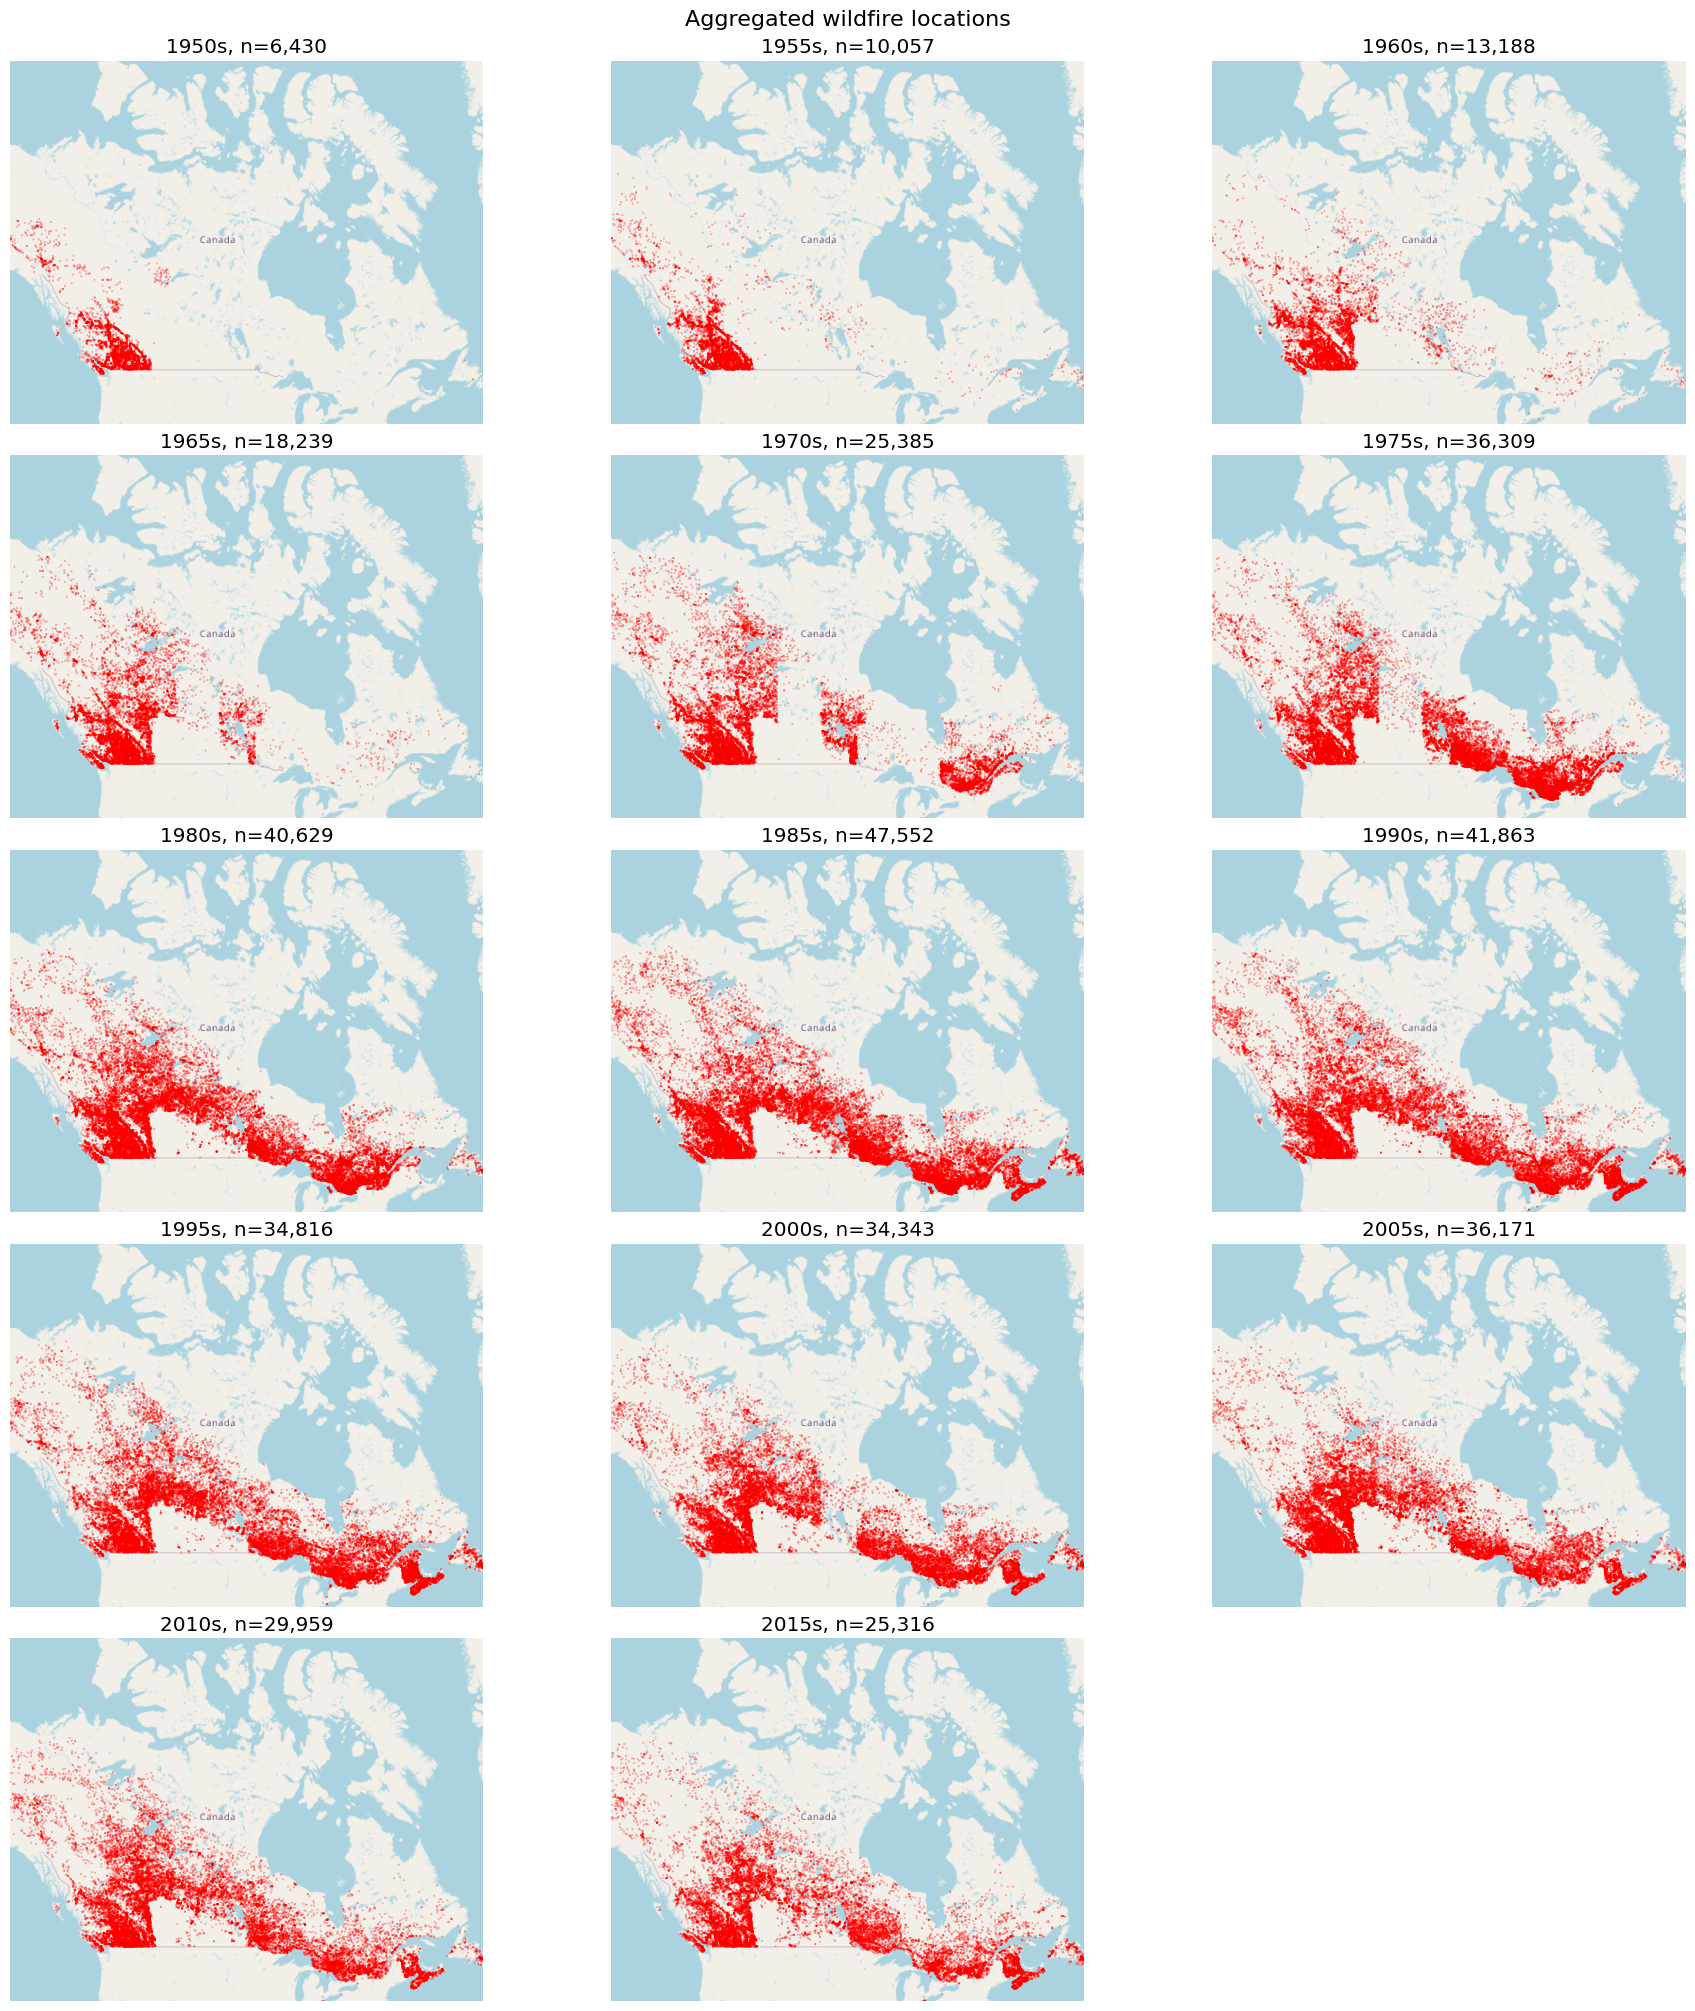

In [50]:
bins = pd.date_range(start =  pd.Timestamp(fires["REP_DATE"].dt.year.min(), 1, 1),
                     end = pd.Timestamp(fires["REP_DATE"].dt.year.max(), 12, 31),
                     freq = "5YE")

titles  = [f"{year}s, n="+ f"{count:,}" for year,count  in zip(bins[:-1].year, fires.groupby(pd.cut(fires["REP_DATE"], bins)).size().values)]
fig_kwargs = {"fname":Path(assets_folder, "plots", "wildfires_5Y.png"),
                  "dpi":300, "bbox_inches": "tight", "pad_inches":0}
suptitle_kwargs = {"fontsize":16, "t": "Aggregated wildfire locations"}
fig, ax = pointplot_grouped(fires, bins, "REP_DATE", titles = titles, webmap = canada, extent = extent,
                                fig_kwargs=fig_kwargs, suptitle_kwargs=suptitle_kwargs)

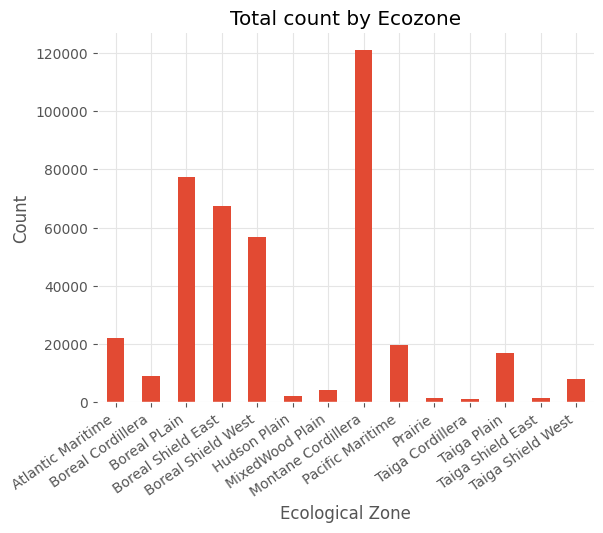

<Figure size 640x480 with 0 Axes>

In [ ]:
fires.groupby("ECOZ_NAME")["ECOZ_NAME"].value_counts().plot(kind = "bar")
plt.xticks(rotation = 35, ha = "right")
plt.xlabel("Ecological Zone")
plt.ylabel("Count")
plt.title("Total count by Ecozone")
plt.show()
save_fig("count_econzone")

We also have data on the size of burned area which can be considered as a mark associated with each point. Its distribution will typically be skewed. Due to the scaling of area consider a log scale:

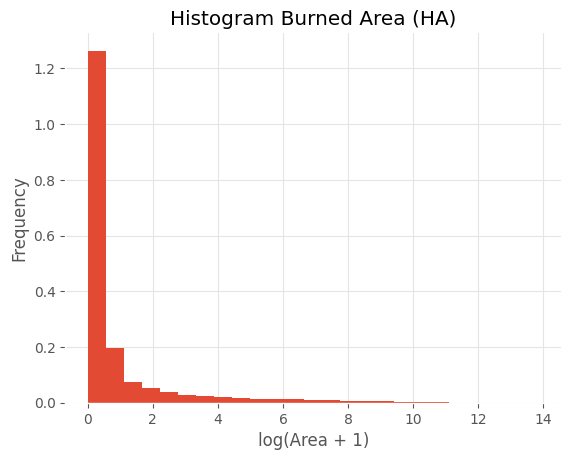

<Figure size 640x480 with 0 Axes>

In [42]:
fires["SIZE_HA_LOG"].plot(kind = "hist",bins = 25,  density = True)
plt.title("Histogram Burned Area (HA)")
plt.xlabel("log(Area + 1)")
plt.show()
save_fig("hist_burned_area.png")

We can also consider the area distribution by each ecozone:

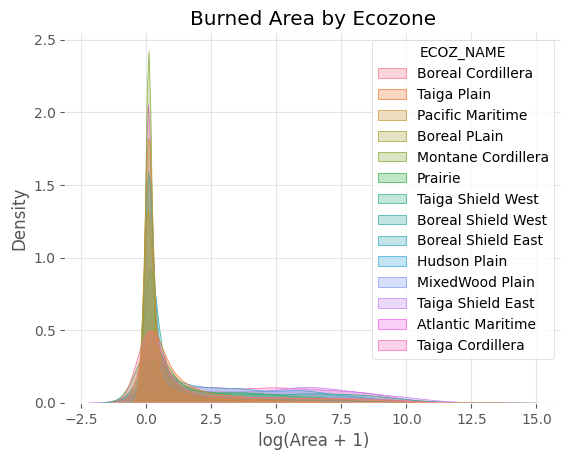

<Figure size 640x480 with 0 Axes>

In [43]:
sns.kdeplot(data=fires, x="SIZE_HA_LOG", hue="ECOZ_NAME",
            fill=True, alpha=0.3, common_norm=False)
plt.xlabel("log(Area + 1)")
plt.title("Burned Area by Ecozone")
plt.show()
save_fig("kde_burned_area_ecozone.png")

To get an idea on the temporal distribution of wildfires we can check the total counts per year:

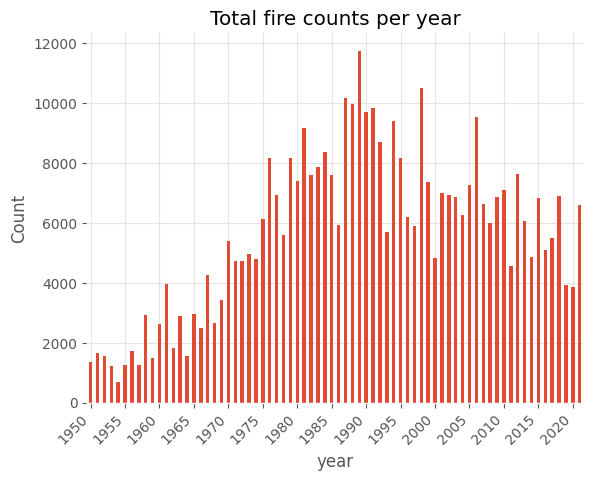

<Figure size 640x480 with 0 Axes>

In [44]:
ax = fires["year"].value_counts().sort_index().plot(kind = "bar")
ax.xaxis.set_major_locator(MultipleLocator(5))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.title("Total fire counts per year")
plt.ylabel("Count")
plt.show()
save_fig("count_year.png")

Instead of plotting on a yearly basis the seasonal pattern becomes more apparent when considering a monthly basis:

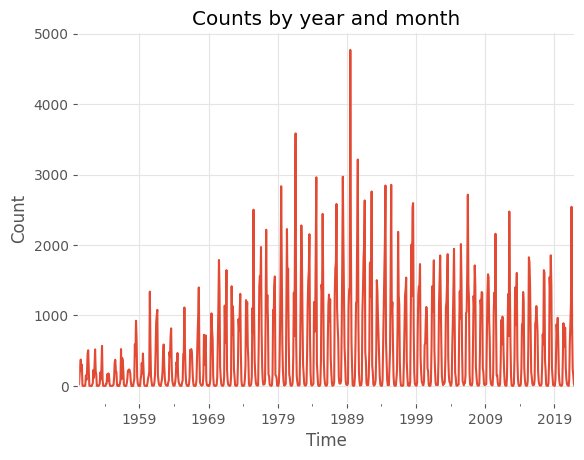

In [45]:
fires.groupby(pd.Grouper(key= "REP_DATE", freq = "ME")) \
    .size() \
    .plot() \
    .set(xlabel = "Time", ylabel = "Count", title = "Counts by year and month")
save_fig("counts_month_year.png")

Doing the same but considering each ecozone seperately shows that mose wildfires occur typically in boreal areas (probably as expected) but also in other ecozones albeit on a somewhat smaller scale:

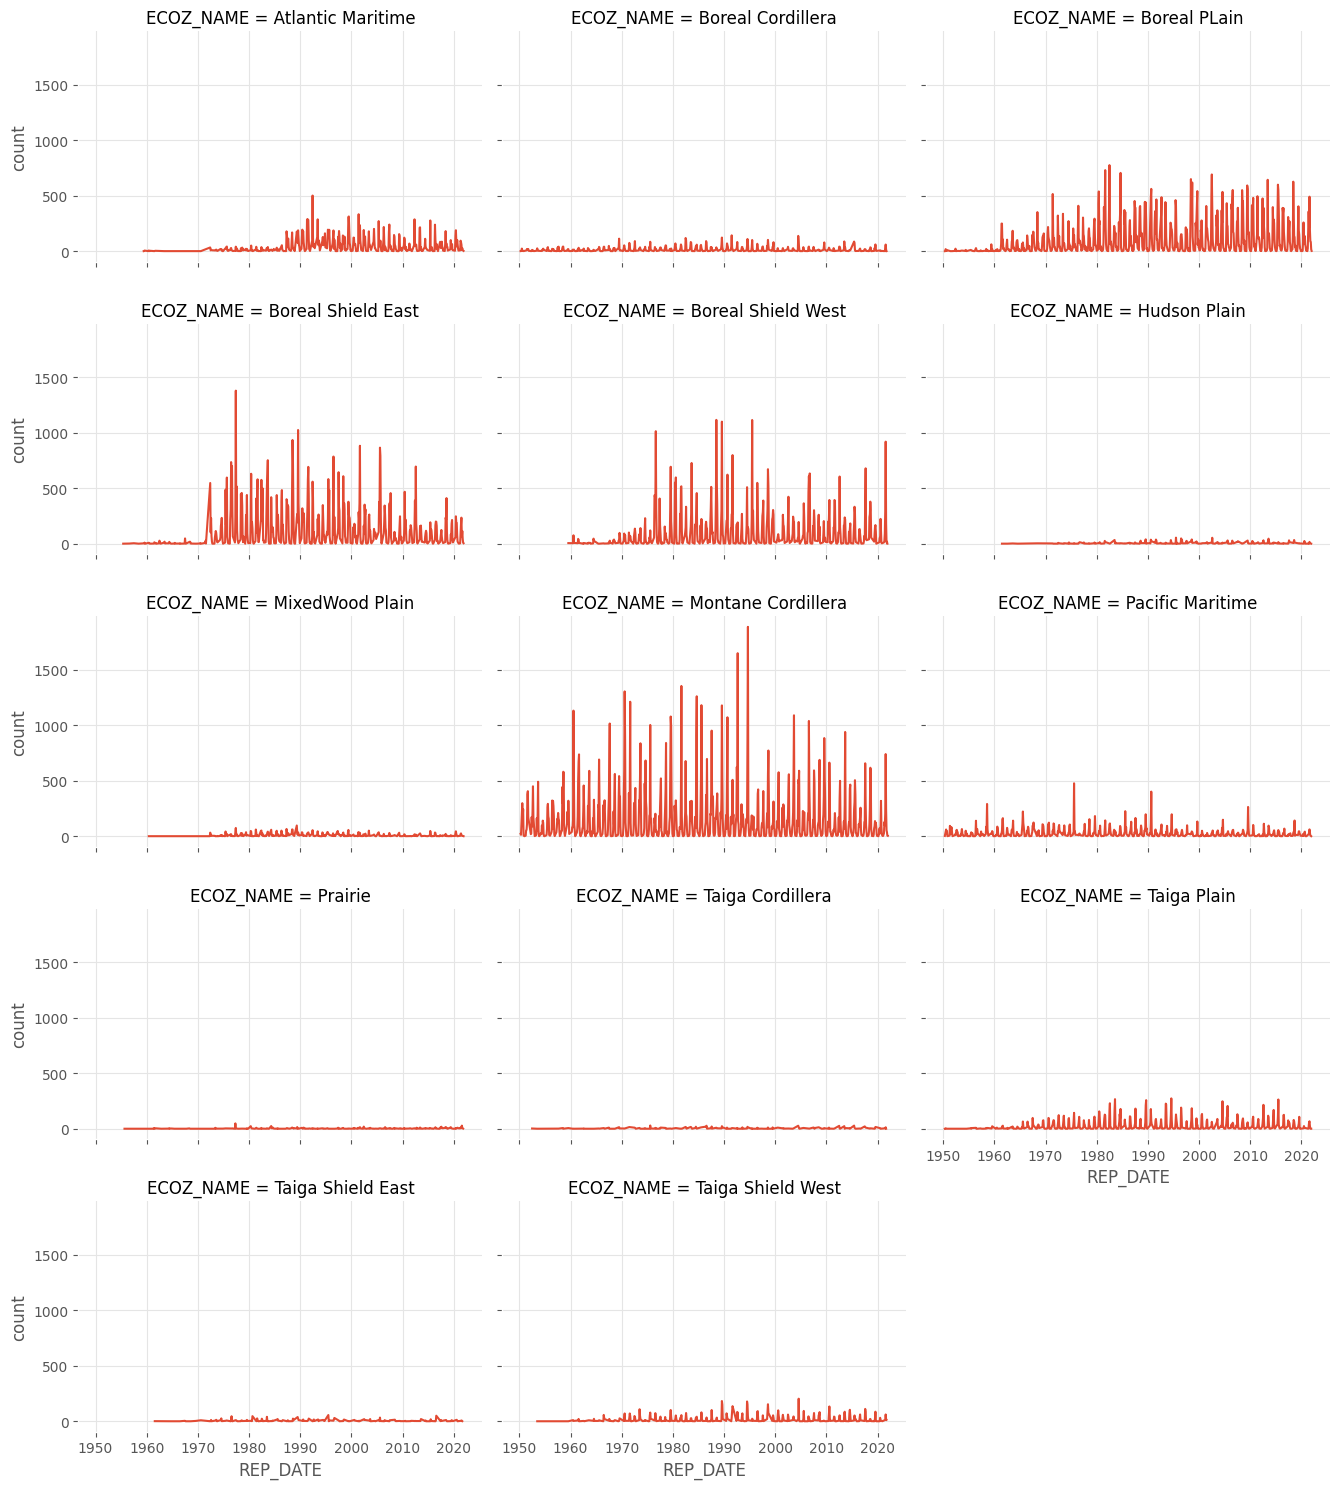

In [46]:
fires.groupby(["ECOZ_NAME", pd.Grouper(key = "REP_DATE", freq = "ME")]) \
    .size() \
    .reset_index(name = "count") \
    .pipe(lambda d: sns.relplot(data = d, x = "REP_DATE", y = "count", kind = "line", col = "ECOZ_NAME",
                                col_wrap=3, height = 3, aspect = 1.5))
save_fig("ts_fires_ecozone.png")

## Exploratory Analysis

Create a PointPattern object of wildfire observations:

In [48]:
fires_pp = PointPattern(np.array([[p.x, p.y] for p in fires.geometry]))

We could consider nearest neighbor distances, altough this would be meaningful for a homoheneous Point Process only which is unlikely to be the  case since we observe spatio(-temporal) clustering:

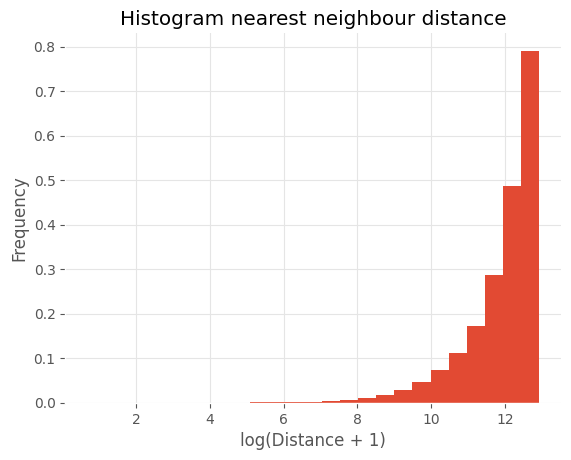

<Figure size 640x480 with 0 Axes>

In [49]:
plt.hist(np.log1p(fires_pp.knn(k=2)[0][:, 1]), bins = 25, density=True)
plt.xlabel("log(Distance + 1)")
plt.ylabel("Frequency")
plt.title("Histogram nearest neighbour distance")
plt.show()
save_fig("distance_1nn.png")